In [136]:
#path = "https://drive.google.com/file/d/1_R27ULD994worFTYPjPzNMRcfropM3Iq/view?usp=drive_link"
path = "/content/train_28jul.csv"

In [137]:
import pandas as pd
df = pd.read_csv(path)

In [138]:
import matplotlib.pyplot as plt

In [139]:
import numpy as np

In [140]:
'''
df_copy = df.copy()
df_mean_copy = df_mean.copy()
'''

'\ndf_copy = df.copy()\ndf_mean_copy = df_mean.copy()\n'

In [141]:
target = df[ 'LotArea' ]
median_value = target.median()

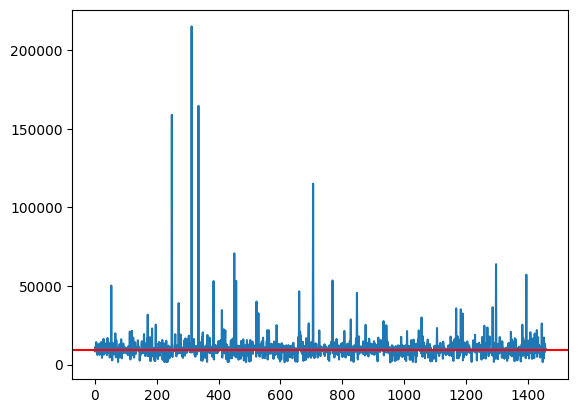

In [142]:
plt.plot( target )
plt.axhline( median_value, color = 'red' )
plt.show()

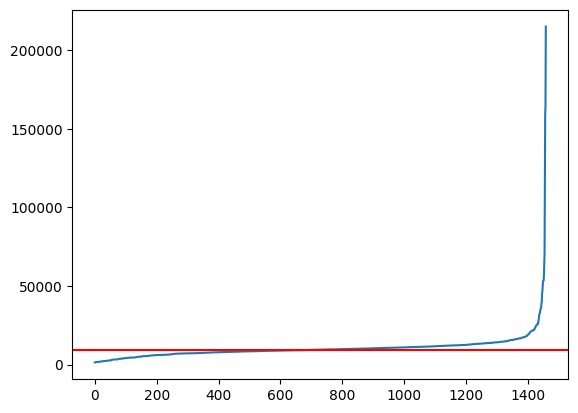

In [143]:
sorted_target =  np.sort( target )
plt.plot( sorted_target )
plt.axhline( median_value, color = 'red' )
plt.show()

In [144]:
target.describe().loc[ ['25%', '50%', '75%'] ]

,LotArea
25%,7553.5
50%,9478.5
75%,11601.5


In [145]:
q1 = target.quantile( 0.25 )
q2 = target.quantile( 0.5 )
q3 = target.quantile( 0.75 )

iqr = q3 - q1
print( f"iqr : {iqr}" )

LL = q1 - 1.5 * iqr
UL = q3 + 1.5 * iqr

print( f"lower limit : { LL }" )
print( f"upper limit : { UL }" )

iqr : 4048.0
lower limit : 1481.5
upper limit : 17673.5


In [146]:
lower_outlier_count = target[ target < LL ]
upper_outlier_count = target[ target > UL ]

print( f"lower outliers : {len(lower_outlier_count)}" )
print( f"upper outliers : {len(upper_outlier_count)}" )

valid_values = target[ (target > LL) & (target < UL) ]
print( f"valid values : {len(valid_values)}" )


lower outliers : 2
upper outliers : 67
valid values : 1391


In [147]:
valid_values.describe()

,LotArea
count,1391.000000
mean,9272.537024
std,3196.732418
min,1491.000000
25%,7429.000000
50%,9286.000000
75%,11231.500000
max,17671.000000


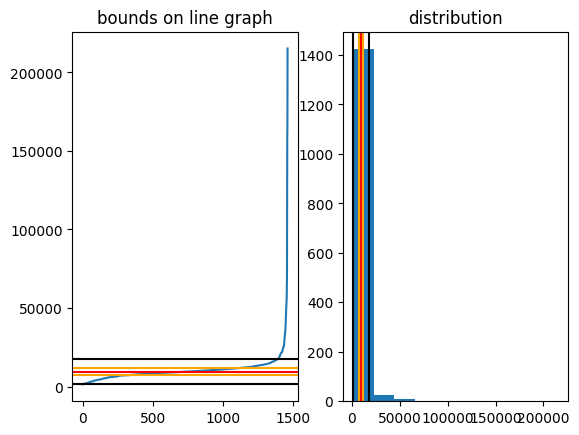

In [148]:
plt.subplot( 1,2,1 )
plt.plot( sorted_target )
plt.axhline( LL, color = 'black' )
plt.axhline( q1, color = 'orange' )
plt.axhline( median_value, color = 'red' )
plt.axhline( q3, color = 'orange' )
plt.axhline( UL, color = 'black' )
plt.title( "bounds on line graph" )

plt.subplot( 1,2,2 )
plt.hist( sorted_target )
plt.axvline( LL, color = 'black' )
plt.axvline( UL, color = 'black' )
plt.axvline( median_value, color = 'red' )
plt.axvline( q1, color = 'orange' )
plt.axvline( q3, color = 'orange' )
plt.title( "distribution" )

plt.show()

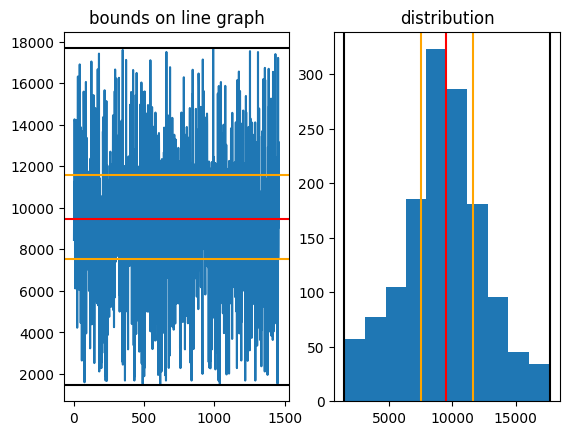

In [149]:
plt.subplot( 1,2,1 )
plt.plot( valid_values )
plt.axhline( LL, color = 'black' )
plt.axhline( UL, color = 'black' )
plt.axhline( median_value, color = 'red' )
plt.axhline( q1, color = 'orange' )
plt.axhline( q3, color = 'orange' )
plt.title( "bounds on line graph" )

plt.subplot( 1,2,2 )
plt.hist( valid_values )
plt.axvline( LL, color = 'black' )
plt.axvline( UL, color = 'black' )
plt.axvline( median_value, color = 'red' )
plt.axvline( q1, color = 'orange' )
plt.axvline( q3, color = 'orange' )
plt.title( "distribution" )

plt.show()

In [150]:
'''
split_index = 0
low_bound = 0
high_bound = len(sorted_target) - 1
mid = int(high_bound)/2
isFound = False
while( isFound!=True ) :
  mid = int(high_bound - low_bound/2)
  if( sorted_target[ mid ] == median_value or ( (sorted_target[ mid ] < median_value)  and (sorted_target[ mid + 1 ] > median_value) ) ) :
    split_index = mid
    isFound = True
  elif( sorted_target[ mid ] > median_value ) :
    high_bound = mid
  else :
    low_bound = mid

smaller_values = sorted_target[ :split_index ].copy()
q1_value = smaller_values.median()
larger_values = sorted_target[ split_index: ].copy()
q3_values = larger_values.median()
'''

'\nsplit_index = 0\nlow_bound = 0\nhigh_bound = len(sorted_target) - 1\nmid = int(high_bound)/2\nisFound = False\nwhile( isFound!=True ) :\n  mid = int(high_bound - low_bound/2)\n  if( sorted_target[ mid ] == median_value or ( (sorted_target[ mid ] < median_value)  and (sorted_target[ mid + 1 ] > median_value) ) ) :\n    split_index = mid\n    isFound = True\n  elif( sorted_target[ mid ] > median_value ) :\n    high_bound = mid\n  else :\n    low_bound = mid\n\nsmaller_values = sorted_target[ :split_index ].copy()\nq1_value = smaller_values.median()\nlarger_values = sorted_target[ split_index: ].copy()\nq3_values = larger_values.median()\n'

In [151]:

#np.find_index( target = median_value )